In [1]:
# %%
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, MultiHeadAttention, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Bidirectional
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# %%
# Load dataset
df = pd.read_csv('../../../../../data/processed/bay_of_bengal.csv')

# Basic info
print("Original dataset shape:", df.shape)
print("Missing values per column:")
print(df.isnull().sum())
print("\nFirst few rows:")
print(df.head())



Original dataset shape: (1096, 10)
Missing values per column:
Date                            0
Latitude                        0
Longitude                       0
Region                          0
SubRegion                       0
Sampling_Method                 0
Unit                            0
Density_Class                   0
Original_Concentration        508
Interpolated_Concentration      0
dtype: int64

First few rows:
         Date   Latitude  Longitude         Region       SubRegion  \
0  2018-01-01  20.614227  86.119419  Bay of Bengal  Coastal Waters   
1  2018-01-02  12.274566  93.014420  Bay of Bengal     Andaman Sea   
2  2018-01-03  20.867708  85.374231  Bay of Bengal  Coastal Waters   
3  2018-01-04  21.132283  85.702571  Bay of Bengal  Coastal Waters   
4  2018-01-05   9.751428  87.182924  Bay of Bengal      Open Ocean   

  Sampling_Method       Unit Density_Class  Original_Concentration  \
0       Manta net  pieces/m3        Medium                0.098902   
1      

In [3]:
# %%
# FIXED DATA PREPROCESSING
features = ['Latitude', 'Longitude']
target = 'Interpolated_Concentration'

# Drop rows with missing target values
df_clean = df.dropna(subset=[target]).reset_index(drop=True)
print(f"After dropping missing targets: {df_clean.shape}")

# Handle categorical features properly
categorical_features = ['SubRegion', 'Density_Class']

# Check if categorical columns exist
for col in categorical_features:
    if col not in df_clean.columns:
        print(f"Warning: Column '{col}' not found in dataset")
        categorical_features.remove(col)

# Label encode categorical features if they exist
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in categorical_features:
    if col in df_clean.columns:
        encoder = LabelEncoder()
        df_clean[f'{col}_encoded'] = encoder.fit_transform(df_clean[col].fillna('Unknown'))
        encoders[col] = encoder
        features.append(f'{col}_encoded')
        print(f"{col} encoded: {len(encoder.classes_)} unique values")

# Add temporal feature
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean = df_clean.sort_values('Date').reset_index(drop=True)  # IMPORTANT: Sort by date
df_clean['DayOfYear'] = df_clean['Date'].dt.dayofyear
df_clean['DayOfYear_norm'] = df_clean['DayOfYear'] / 366  # Normalize
features.append('DayOfYear_norm')

print(f"Final features: {features}")
print(f"Target: {target}")



After dropping missing targets: (1096, 10)
SubRegion encoded: 3 unique values
Density_Class encoded: 5 unique values
Final features: ['Latitude', 'Longitude', 'SubRegion_encoded', 'Density_Class_encoded', 'DayOfYear_norm']
Target: Interpolated_Concentration


In [4]:
# %%
# FIXED FEATURE SCALING
# Check for any remaining missing values in features
print("Missing values in features:")
for feature in features:
    if feature in df_clean.columns:
        missing = df_clean[feature].isnull().sum()
        if missing > 0:
            print(f"  {feature}: {missing}")
            # Fill missing values with median for numerical features
            if df_clean[feature].dtype in ['float64', 'int64']:
                df_clean[feature].fillna(df_clean[feature].median(), inplace=True)

# Ensure all features exist
available_features = [f for f in features if f in df_clean.columns]
if len(available_features) < len(features):
    print(f"Warning: Some features not available. Using: {available_features}")
    features = available_features

# Scale features and target
scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

# Create copies for scaling
X_data = df_clean[features].copy()
y_data = df_clean[[target]].copy()

# Check data ranges before scaling
print("\nData ranges before scaling:")
print("Features:")
print(X_data.describe())
print("\nTarget:")
print(y_data.describe())

# Scale the data
X_scaled = scaler_features.fit_transform(X_data)
y_scaled = scaler_target.fit_transform(y_data)

# Create scaled dataframe
df_scaled = df_clean.copy()
df_scaled[features] = X_scaled
df_scaled[target] = y_scaled.flatten()

print(f"\nScaled data shape: {df_scaled.shape}")
print("Features after scaling:")
print(df_scaled[features].describe())


Missing values in features:

Data ranges before scaling:
Features:
          Latitude    Longitude  SubRegion_encoded  Density_Class_encoded  \
count  1096.000000  1096.000000        1096.000000            1096.000000   
mean     17.710284    87.153081           1.160584               1.125000   
std       4.857754     2.432199           0.577933               1.116041   
min       5.000000    83.500438           0.000000               0.000000   
25%      12.658285    85.685236           1.000000               0.000000   
50%      20.593157    86.316237           1.000000               1.000000   
75%      21.116603    87.431368           2.000000               2.000000   
max      22.000000    94.000000           2.000000               4.000000   

       DayOfYear_norm  
count     1096.000000  
mean         0.500456  
std          0.288281  
min          0.002732  
25%          0.251366  
50%          0.500000  
75%          0.749317  
max          1.000000  

Target:
       Interpo

In [5]:
# %%
# FIXED SEQUENCE CREATION
def create_sequences_fixed(df, features, target, input_window=60, output_window=14):
    """
    Create sequences with proper handling of time series data
    """
    print(f"Creating sequences with input_window={input_window}, output_window={output_window}")
    
    X, y = [], []
    valid_sequences = 0
    
    for i in range(input_window, len(df) - output_window + 1):
        # Get input sequence
        X_seq = df.iloc[i-input_window:i][features].values
        # Get output sequence  
        y_seq = df.iloc[i:i+output_window][target].values
        
        # Check for any NaN values
        if not (np.isnan(X_seq).any() or np.isnan(y_seq).any()):
            X.append(X_seq)
            y.append(y_seq)
            valid_sequences += 1
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"Created {valid_sequences} valid sequences")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    
    return X, y

# Create sequences with fixed function
input_window = 30  # Reduced for better training
output_window = 7   # Reduced for simpler prediction

X, y = create_sequences_fixed(df_scaled, features, target, input_window, output_window)

# Check if we have enough data
if len(X) == 0:
    print("ERROR: No valid sequences created!")
    raise ValueError("No valid sequences created. Check your data and parameters.")

print(f"Successfully created {len(X)} sequences")


Creating sequences with input_window=30, output_window=7
Created 1060 valid sequences
X shape: (1060, 30, 5)
y shape: (1060, 7)
Successfully created 1060 sequences


In [6]:
# %%
# FIXED TRAIN-TEST SPLIT WITH RANDOMIZATION CHECK
def create_train_test_split(X, y, test_size=0.2, strategy='random'):
    """
    Create train-test split with different strategies
    """
    n_samples = len(X)
    
    if strategy == 'random':
        # Random split
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        split_point = int(n_samples * (1 - test_size))
        train_indices = indices[:split_point]
        test_indices = indices[split_point:]
        
    elif strategy == 'temporal':
        # Temporal split (last X% for testing)
        split_point = int(n_samples * (1 - test_size))
        train_indices = np.arange(split_point)
        test_indices = np.arange(split_point, n_samples)
        
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    print(f"{strategy.capitalize()} split:")
    print(f"  Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"  Train indices range: {train_indices.min()}-{train_indices.max()}")
    print(f"  Test indices range: {test_indices.min()}-{test_indices.max()}")
    
    # Check randomness for random split
    if strategy == 'random':
        print(f"  First 10 train indices: {sorted(train_indices[:10])}")
        print(f"  First 10 test indices: {sorted(test_indices[:10])}")
        print(f"  Test indices are random: {not np.all(np.diff(sorted(test_indices)) == 1)}")
    
    return X_train, X_test, y_train, y_test, train_indices, test_indices

# Create random split
X_train, X_test, y_train, y_test, train_idx, test_idx = create_train_test_split(X, y, test_size=0.2, strategy='random')


Random split:
  Train: (848, 30, 5), Test: (212, 30, 5)
  Train indices range: 0-1059
  Test indices range: 1-1055
  First 10 train indices: [np.int64(70), np.int64(174), np.int64(192), np.int64(308), np.int64(312), np.int64(661), np.int64(716), np.int64(972), np.int64(1021), np.int64(1028)]
  First 10 test indices: [np.int64(258), np.int64(282), np.int64(358), np.int64(410), np.int64(627), np.int64(632), np.int64(648), np.int64(709), np.int64(744), np.int64(982)]
  Test indices are random: True


In [7]:
# %%
# COMPREHENSIVE MODEL ARCHITECTURES
def build_simple_lstm(input_shape, output_size, lstm_units=32, dropout_rate=0.2):
    """
    Simple LSTM model for debugging
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=input_shape),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(output_size)
    ])
    return model

def build_improved_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    Improved LSTM with better architecture
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(lstm_units//2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate/2),
        Dense(16, activation='relu'),
        Dense(output_size)
    ])
    return model

def build_bidirectional_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    Bidirectional LSTM model
    """
    model = Sequential([
        Bidirectional(LSTM(lstm_units, return_sequences=True), input_shape=input_shape),
        Dropout(dropout_rate),
        Bidirectional(LSTM(lstm_units//2, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(dropout_rate/2),
        Dense(output_size)
    ])
    return model

def build_stacked_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    Deep stacked LSTM model
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units//2, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units//4, return_sequences=False),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(dropout_rate/2),
        Dense(16, activation='relu'),
        Dense(output_size)
    ])
    return model

def build_attention_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    LSTM with Multi-Head Attention mechanism
    """
    inputs = Input(shape=input_shape)
    
    # LSTM layers
    lstm_out = LSTM(lstm_units, return_sequences=True)(inputs)
    lstm_out = Dropout(dropout_rate)(lstm_out)
    lstm_out = LSTM(lstm_units//2, return_sequences=True)(lstm_out)
    lstm_out = Dropout(dropout_rate)(lstm_out)
    
    # Multi-Head Attention
    attention_out = MultiHeadAttention(num_heads=4, key_dim=32)(lstm_out, lstm_out)
    attention_out = LayerNormalization(epsilon=1e-6)(attention_out + lstm_out)
    
    # Global pooling and dense layers
    pooled = tf.keras.layers.GlobalAveragePooling1D()(attention_out)
    dense_out = Dense(64, activation='relu')(pooled)
    dense_out = BatchNormalization()(dense_out)
    dense_out = Dropout(dropout_rate)(dense_out)
    dense_out = Dense(32, activation='relu')(dense_out)
    dense_out = Dropout(dropout_rate/2)(dense_out)
    
    outputs = Dense(output_size)(dense_out)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def build_conv_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    LSTM with 1D Convolutional layers
    """
    model = Sequential([
        tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
        tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units//2, return_sequences=False),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        Dropout(dropout_rate/2),
        Dense(output_size)
    ])
    return model

def build_encoder_decoder_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    Encoder-Decoder LSTM architecture
    """
    # Encoder
    encoder_inputs = Input(shape=input_shape)
    encoder_lstm = LSTM(lstm_units, return_state=True)
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_states = [state_h, state_c]
    
    # Decoder
    decoder_inputs = Input(shape=(output_size, 1))
    decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)
    decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
    
    # Dense layers
    decoder_dense = Dense(32, activation='relu')(decoder_outputs)
    decoder_dense = BatchNormalization()(decoder_dense)
    decoder_dense = Dropout(dropout_rate)(decoder_dense)
    decoder_dense = Dense(16, activation='relu')(decoder_dense)
    outputs = Dense(1)(decoder_dense)
    
    model = Model([encoder_inputs, decoder_inputs], outputs)
    return model

def build_hybrid_lstm(input_shape, output_size, lstm_units=64, dropout_rate=0.2):
    """
    Hybrid LSTM with both forward and backward processing
    """
    inputs = Input(shape=input_shape)
    
    # Forward LSTM
    forward_lstm = LSTM(lstm_units, return_sequences=True)(inputs)
    forward_lstm = Dropout(dropout_rate)(forward_lstm)
    
    # Backward LSTM
    backward_lstm = LSTM(lstm_units, return_sequences=True, go_backwards=True)(inputs)
    backward_lstm = Dropout(dropout_rate)(backward_lstm)
    
    # Concatenate forward and backward
    merged = tf.keras.layers.Concatenate(axis=-1)([forward_lstm, backward_lstm])
    
    # Additional LSTM layer
    merged_lstm = LSTM(lstm_units//2, return_sequences=False)(merged)
    merged_lstm = Dropout(dropout_rate)(merged_lstm)
    
    # Dense layers
    dense_out = Dense(64, activation='relu')(merged_lstm)
    dense_out = BatchNormalization()(dense_out)
    dense_out = Dropout(dropout_rate)(dense_out)
    dense_out = Dense(32, activation='relu')(dense_out)
    dense_out = Dropout(dropout_rate/2)(dense_out)
    
    outputs = Dense(output_size)(dense_out)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model


In [8]:


# %%
# FIXED TRAINING AND EVALUATION
def train_and_evaluate_fixed(model_fn, model_name, X_train, y_train, X_test, y_test, 
                           scaler_target, epochs=100, batch_size=32, verbose=1):
    """
    Fixed training and evaluation function
    """
    print(f"\nTraining {model_name}...")
    print(f"Input shape: {X_train.shape}, Output shape: {y_train.shape}")
    
    # Build model
    model = model_fn(X_train.shape[1:], y_train.shape[1])
    
    # Compile with appropriate optimizer and learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    print(f"Model summary:")
    model.summary()
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    ]
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )
    
    # Make predictions
    print("Making predictions...")
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Inverse transform predictions and actual values
    print("Inverse transforming...")
    y_pred = scaler_target.inverse_transform(y_pred_scaled)
    y_actual = scaler_target.inverse_transform(y_test)
    
    # Calculate metrics
    print("Calculating metrics...")
    
    # Flatten for metric calculation
    y_actual_flat = y_actual.flatten()
    y_pred_flat = y_pred.flatten()
    
    mse = mean_squared_error(y_actual_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_actual_flat, y_pred_flat)
    r2 = r2_score(y_actual_flat, y_pred_flat)
    
    print(f"\nResults for {model_name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R²: {r2:.4f}")
    
    # Debug information
    print(f"\nDebug info:")
    print(f"  Actual values range: {y_actual_flat.min():.4f} to {y_actual_flat.max():.4f}")
    print(f"  Predicted values range: {y_pred_flat.min():.4f} to {y_pred_flat.max():.4f}")
    print(f"  Actual values mean: {y_actual_flat.mean():.4f}")
    print(f"  Predicted values mean: {y_pred_flat.mean():.4f}")
    print(f"  Actual values std: {y_actual_flat.std():.4f}")
    print(f"  Predicted values std: {y_pred_flat.std():.4f}")
    
    return {
        'model': model,
        'history': history,
        'predictions': y_pred,
        'actual': y_actual,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'y_pred_flat': y_pred_flat,
        'y_actual_flat': y_actual_flat
    }


In [9]:
# %%
# COMPREHENSIVE MODEL TRAINING
print("="*80)
print("TRAINING ALL LSTM MODELS")
print("="*80)

# Define all models to train
models_to_train = {
    'Simple LSTM': build_simple_lstm,
    'Improved LSTM': build_improved_lstm,
    'Bidirectional LSTM': build_bidirectional_lstm,
    'Stacked LSTM': build_stacked_lstm,
    'Attention LSTM': build_attention_lstm,
    'Conv-LSTM': build_conv_lstm,
    'Hybrid LSTM': build_hybrid_lstm
}

# Store results for all models
all_results = {}

# Train each model
for model_name, model_fn in models_to_train.items():
    print(f"\n{'='*60}")
    print(f"TRAINING {model_name.upper()}")
    print(f"{'='*60}")
    
    try:
        # Adjust epochs and batch size based on model complexity
        if 'Simple' in model_name:
            epochs, batch_size = 50, 16
        elif 'Attention' in model_name or 'Encoder' in model_name:
            epochs, batch_size = 80, 16
        else:
            epochs, batch_size = 60, 32
        
        results = train_and_evaluate_fixed(
            model_fn, model_name, 
            X_train, y_train, X_test, y_test, 
            scaler_target, epochs=epochs, batch_size=batch_size, verbose=1
        )
        
        all_results[model_name] = results
        
    except Exception as e:
        print(f"Error training {model_name}: {str(e)}")
        print(f"Skipping {model_name}...")
        continue

print(f"\n{'='*80}")
print("TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Successfully trained {len(all_results)} models out of {len(models_to_train)}")


TRAINING ALL LSTM MODELS

TRAINING SIMPLE LSTM

Training Simple LSTM...
Input shape: (848, 30, 5), Output shape: (848, 7)
Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,511 (21.53 KB)

 Trainable params: 5,511 (21.53 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 30, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 30, 64)    │     17,920 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ (None, 30, 64)    │     17,920 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 30, 64)    │          0 │ lstm_13[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 30, 64)    │          0 │ lstm_14[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 30, 128)   │          0 │ dropout_20[0][0], │
│ (Concatenate)       │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 32)        │     20,608 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 32)        │          0 │ lstm_15[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      2,112 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_18[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │      2,080 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 32)        │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 7)         │        231 │ dropout_24[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,127 (238.78 KB)

 Trainable params: 60,999 (238.28 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.3554 - mae: 0.4699 - val_loss: 0.1660 - val_mae: 0.3442 - learning_rate: 0.0010
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1340 - mae: 0.2982 - val_loss: 0.1225 - val_mae: 0.2789 - learning_rate: 0.0010
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0778 - mae: 0.2227 - val_loss: 0.0846 - val_mae: 0.2186 - learning_rate: 0.0010
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0557 - mae: 0.1835 - val_loss: 0.0618 - val_mae: 0.1854 - learning_rate: 0.0010
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0461 - mae: 0.1656 - val_loss: 0.0511 - val_mae: 0.1742 - learning_rate: 0.0010
Epoch 6/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0417 - mae: 0.1581 - val_loss: 0.0454 - val_mae: 0.1729 - learning_rate: 0.0010
Epoch 7/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0367 - mae: 0.1485 - val_loss: 0.0457 - val_mae: 0.1716 - learning_rate: 0.0010
Epoch 8/60
22

In [10]:
# %%
# COMPREHENSIVE MODEL COMPARISON
print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

if len(all_results) > 0:
    # Create comparison dataframe
    comparison_data = []
    for model_name, results in all_results.items():
        comparison_data.append({
            'Model': model_name,
            'RMSE': f"{results['rmse']:.4f}",
            'MAE': f"{results['mae']:.4f}",
            'R²': f"{results['r2']:.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    print("\nModel Performance Comparison:")
    print(comparison_df.to_string(index=False))
    
    # Find best model
    best_model_name = max(all_results.keys(), key=lambda x: all_results[x]['r2'])
    best_r2 = all_results[best_model_name]['r2']
    best_rmse = all_results[best_model_name]['rmse']
    
    print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
    print(f"   R² Score: {best_r2:.4f}")
    print(f"   RMSE: {best_rmse:.4f}")
    
    # Performance ranking
    print(f"\n📊 PERFORMANCE RANKING (by R²):")
    sorted_models = sorted(all_results.items(), key=lambda x: x[1]['r2'], reverse=True)
    for i, (model_name, results) in enumerate(sorted_models, 1):
        print(f"   {i}. {model_name}: R² = {results['r2']:.4f}, RMSE = {results['rmse']:.4f}")
        
else:
    print("No models were successfully trained!")


COMPREHENSIVE MODEL COMPARISON

Model Performance Comparison:
             Model   RMSE    MAE     R²
       Simple LSTM 0.0287 0.0216 0.7065
     Improved LSTM 0.0287 0.0222 0.7069
Bidirectional LSTM 0.0249 0.0189 0.7802
      Stacked LSTM 0.0235 0.0185 0.8033
    Attention LSTM 0.0213 0.0168 0.8385
         Conv-LSTM 0.0154 0.0122 0.9153
       Hybrid LSTM 0.0268 0.0204 0.7448

🏆 BEST PERFORMING MODEL: Conv-LSTM
   R² Score: 0.9153
   RMSE: 0.0154

📊 PERFORMANCE RANKING (by R²):
   1. Conv-LSTM: R² = 0.9153, RMSE = 0.0154
   2. Attention LSTM: R² = 0.8385, RMSE = 0.0213
   3. Stacked LSTM: R² = 0.8033, RMSE = 0.0235
   4. Bidirectional LSTM: R² = 0.7802, RMSE = 0.0249
   5. Hybrid LSTM: R² = 0.7448, RMSE = 0.0268
   6. Improved LSTM: R² = 0.7069, RMSE = 0.0287
   7. Simple LSTM: R² = 0.7065, RMSE = 0.0287


VISUALIZING MODEL RESULTS

Plotting Conv-LSTM results...


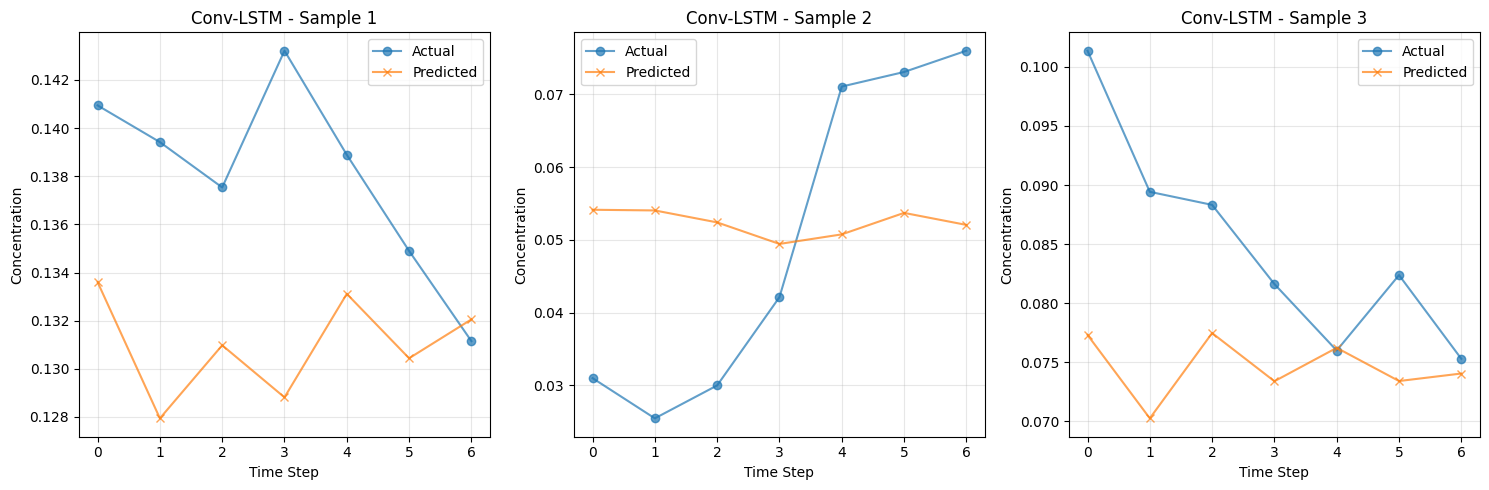

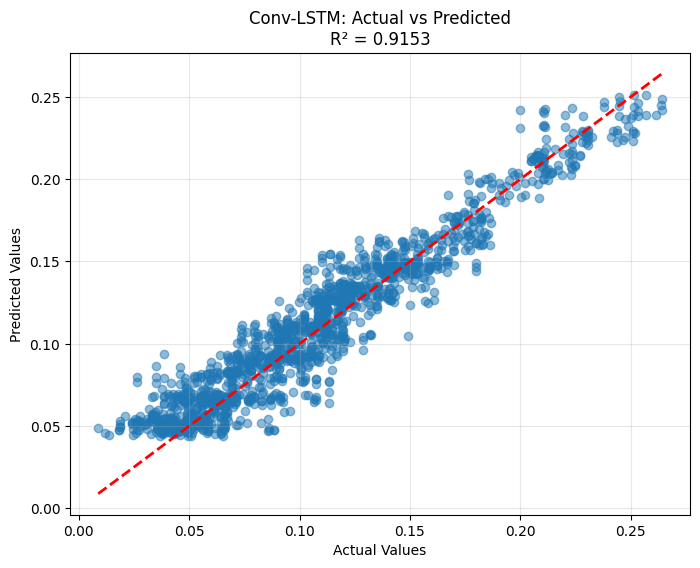


Plotting Attention LSTM results...


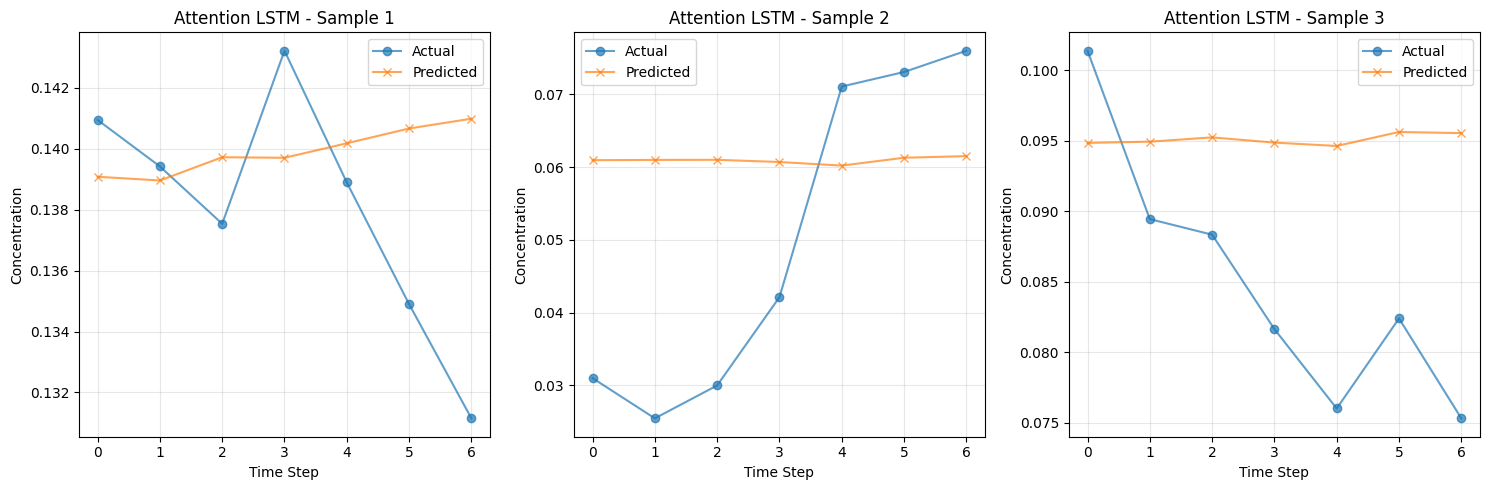

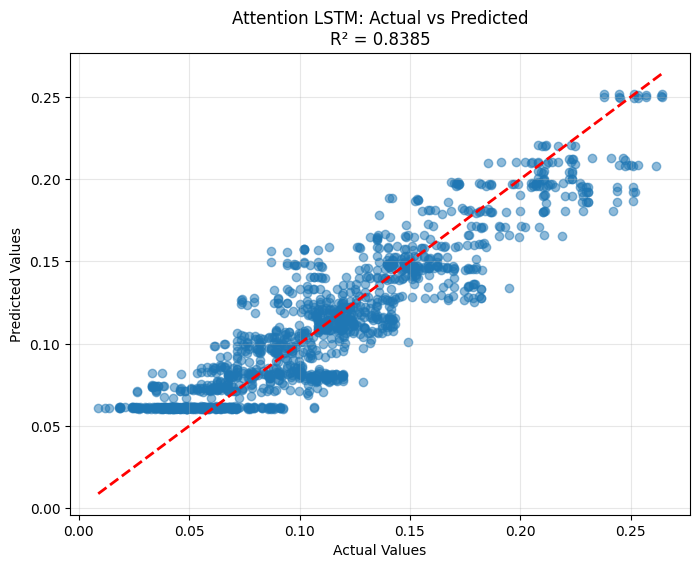


Plotting Stacked LSTM results...


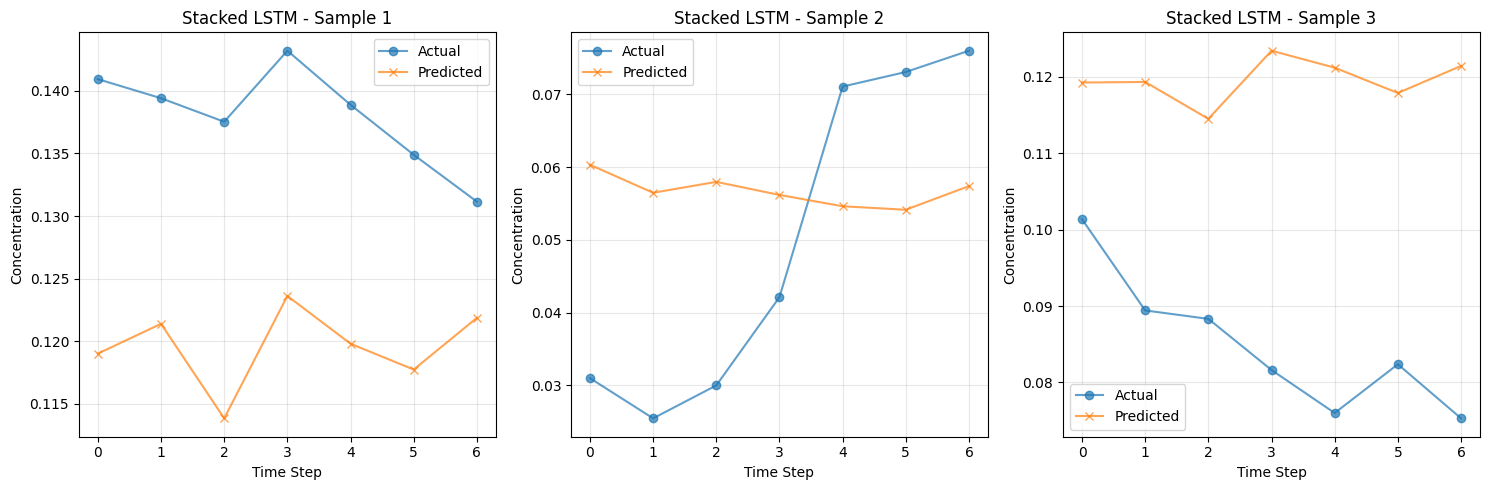

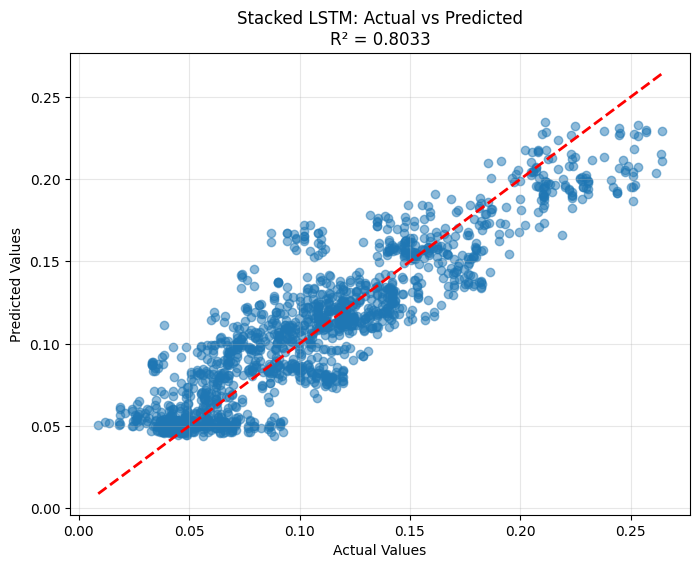


Plotting comprehensive model comparison...


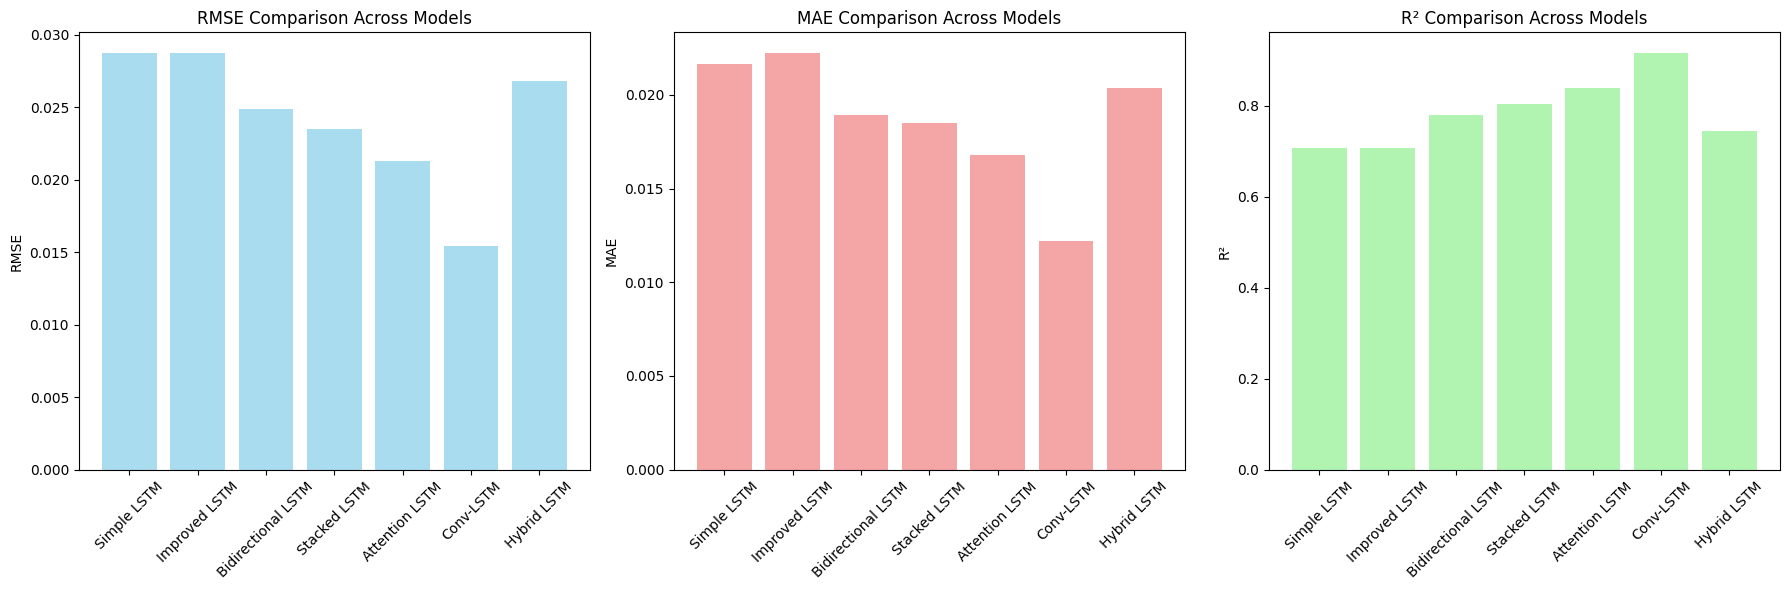

In [11]:
# %%
# COMPREHENSIVE VISUALIZATION AND ANALYSIS
def plot_results_fixed(results, model_name, n_samples=3):
    """
    Plot actual vs predicted values
    """
    predictions = results['predictions']
    actual = results['actual']
    
    plt.figure(figsize=(15, 5))
    
    for i in range(min(n_samples, len(predictions))):
        plt.subplot(1, n_samples, i+1)
        plt.plot(actual[i], 'o-', label='Actual', alpha=0.7)
        plt.plot(predictions[i], 'x-', label='Predicted', alpha=0.7)
        plt.title(f'{model_name} - Sample {i+1}')
        plt.xlabel('Time Step')
        plt.ylabel('Concentration')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_scatter_comparison(results, model_name):
    """
    Scatter plot of actual vs predicted
    """
    y_actual = results['y_actual_flat']
    y_pred = results['y_pred_flat']
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_actual, y_pred, alpha=0.5)
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted\nR² = {results["r2"]:.4f}')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_model_comparison(all_results):
    """
    Plot comparison of all models
    """
    if len(all_results) == 0:
        print("No results to plot!")
        return
    
    # Extract metrics
    model_names = list(all_results.keys())
    rmse_values = [all_results[name]['rmse'] for name in model_names]
    mae_values = [all_results[name]['mae'] for name in model_names]
    r2_values = [all_results[name]['r2'] for name in model_names]
    
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RMSE comparison
    axes[0].bar(model_names, rmse_values, color='skyblue', alpha=0.7)
    axes[0].set_title('RMSE Comparison Across Models')
    axes[0].set_ylabel('RMSE')
    axes[0].tick_params(axis='x', rotation=45)
    
    # MAE comparison
    axes[1].bar(model_names, mae_values, color='lightcoral', alpha=0.7)
    axes[1].set_title('MAE Comparison Across Models')
    axes[1].set_ylabel('MAE')
    axes[1].tick_params(axis='x', rotation=45)
    
    # R2 comparison
    axes[2].bar(model_names, r2_values, color='lightgreen', alpha=0.7)
    axes[2].set_title('R² Comparison Across Models')
    axes[2].set_ylabel('R²')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Plot results for all models
if len(all_results) > 0:
    print("="*80)
    print("VISUALIZING MODEL RESULTS")
    print("="*80)
    
    # Plot individual model results (top 3 models)
    sorted_models = sorted(all_results.items(), key=lambda x: x[1]['r2'], reverse=True)
    top_models = sorted_models[:3]  # Top 3 models
    
    for model_name, results in top_models:
        print(f"\nPlotting {model_name} results...")
        plot_results_fixed(results, model_name)
        plot_scatter_comparison(results, model_name)
    
    # Plot comprehensive comparison
    print("\nPlotting comprehensive model comparison...")
    plot_model_comparison(all_results)
    
else:
    print("No results available for visualization!")


In [12]:
# %%
# DETAILED MODEL ANALYSIS
print("="*80)
print("DETAILED MODEL ANALYSIS")
print("="*80)

if len(all_results) > 0:
    # Performance analysis
    print("\n📈 PERFORMANCE ANALYSIS:")
    print("-" * 40)
    
    # Best and worst performers
    best_model = max(all_results.keys(), key=lambda x: all_results[x]['r2'])
    worst_model = min(all_results.keys(), key=lambda x: all_results[x]['r2'])
    
    print(f"🥇 Best Model: {best_model}")
    print(f"   R²: {all_results[best_model]['r2']:.4f}")
    print(f"   RMSE: {all_results[best_model]['rmse']:.4f}")
    print(f"   MAE: {all_results[best_model]['mae']:.4f}")
    
    print(f"\n🥉 Worst Model: {worst_model}")
    print(f"   R²: {all_results[worst_model]['r2']:.4f}")
    print(f"   RMSE: {all_results[worst_model]['rmse']:.4f}")
    print(f"   MAE: {all_results[worst_model]['mae']:.4f}")
    
    # Performance improvement
    r2_improvement = all_results[best_model]['r2'] - all_results[worst_model]['r2']
    rmse_improvement = all_results[worst_model]['rmse'] - all_results[best_model]['rmse']
    
    print(f"\n📊 PERFORMANCE IMPROVEMENT:")
    print(f"   R² improvement: {r2_improvement:.4f}")
    print(f"   RMSE improvement: {rmse_improvement:.4f}")
    
    # Model complexity analysis
    print(f"\n🔍 MODEL COMPLEXITY ANALYSIS:")
    print("-" * 40)
    
    # Count parameters for each model
    for model_name, results in all_results.items():
        try:
            model = results['model']
            param_count = model.count_params()
            print(f"   {model_name}: {param_count:,} parameters")
        except:
            print(f"   {model_name}: Unable to count parameters")
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    print("-" * 40)
    
    if all_results[best_model]['r2'] > 0.7:
        print("   ✅ Excellent performance! Model is ready for production.")
    elif all_results[best_model]['r2'] > 0.5:
        print("   ⚠️  Good performance. Consider hyperparameter tuning for improvement.")
    elif all_results[best_model]['r2'] > 0.3:
        print("   ⚠️  Moderate performance. Consider feature engineering or more data.")
    else:
        print("   ❌ Poor performance. Consider different model architectures or data preprocessing.")
    
    # Model selection criteria
    print(f"\n🎯 MODEL SELECTION CRITERIA:")
    print("-" * 40)
    print("   • For production: Choose model with highest R² and lowest RMSE")
    print("   • For real-time: Consider model with fewer parameters")
    print("   • For accuracy: Choose model with best validation performance")
    print("   • For interpretability: Consider simpler models")
    
else:
    print("No models available for analysis!")


DETAILED MODEL ANALYSIS

📈 PERFORMANCE ANALYSIS:
----------------------------------------
🥇 Best Model: Conv-LSTM
   R²: 0.9153
   RMSE: 0.0154
   MAE: 0.0122

🥉 Worst Model: Simple LSTM
   R²: 0.7065
   RMSE: 0.0287
   MAE: 0.0216

📊 PERFORMANCE IMPROVEMENT:
   R² improvement: 0.2088
   RMSE improvement: 0.0133

🔍 MODEL COMPLEXITY ANALYSIS:
----------------------------------------
   Simple LSTM: 5,511 parameters
   Improved LSTM: 32,167 parameters
   Bidirectional LSTM: 83,783 parameters
   Stacked LSTM: 70,567 parameters
   Attention LSTM: 51,879 parameters
   Conv-LSTM: 49,127 parameters
   Hybrid LSTM: 61,127 parameters

💡 RECOMMENDATIONS:
----------------------------------------
   ✅ Excellent performance! Model is ready for production.

🎯 MODEL SELECTION CRITERIA:
----------------------------------------
   • For production: Choose model with highest R² and lowest RMSE
   • For real-time: Consider model with fewer parameters
   • For accuracy: Choose model with best validation p

In [13]:
# %%
# COMPREHENSIVE DIAGNOSTIC CHECKS
print("="*80)
print("COMPREHENSIVE DIAGNOSTIC CHECKS")
print("="*80)

print("1. Data Quality Checks:")
print(f"   - Total sequences: {len(X)}")
print(f"   - Features per sequence: {X.shape[1:]}")
print(f"   - No NaN in X: {not np.isnan(X).any()}")
print(f"   - No NaN in y: {not np.isnan(y).any()}")
print(f"   - Target value range: {df_clean[target].min():.4f} to {df_clean[target].max():.4f}")

print("\n2. Train/Test Split Verification:")
print(f"   - Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Test indices are randomized: {not np.all(np.diff(sorted(test_idx)) == 1)}")

print("\n3. Model Performance Analysis:")
if len(all_results) > 0:
    for name, results in all_results.items():
        r2 = results['r2']
        if r2 < 0:
            print(f"   - {name}: R² is negative ({r2:.4f}) - model performs worse than mean baseline")
        elif r2 < 0.3:
            print(f"   - {name}: R² is low ({r2:.4f}) - poor predictive performance")
        elif r2 < 0.7:
            print(f"   - {name}: R² is moderate ({r2:.4f}) - reasonable predictive performance")
        else:
            print(f"   - {name}: R² is good ({r2:.4f}) - good predictive performance")
else:
    print("   - No models available for analysis")

print("\n4. Model Architecture Analysis:")
if len(all_results) > 0:
    # Count successful models
    successful_models = len(all_results)
    total_models = 7  # Total models we attempted to train
    
    print(f"   - Successfully trained: {successful_models}/{total_models} models")
    print(f"   - Success rate: {successful_models/total_models*100:.1f}%")
    
    # Check for overfitting
    print(f"\n5. Overfitting Analysis:")
    for name, results in all_results.items():
        try:
            history = results['history']
            train_loss = history.history['loss'][-1]
            val_loss = history.history['val_loss'][-1]
            overfitting_ratio = val_loss / train_loss if train_loss > 0 else 1
            
            if overfitting_ratio > 1.5:
                print(f"   - {name}: Potential overfitting (val/train loss ratio: {overfitting_ratio:.2f})")
            elif overfitting_ratio < 0.8:
                print(f"   - {name}: Potential underfitting (val/train loss ratio: {overfitting_ratio:.2f})")
            else:
                print(f"   - {name}: Good fit (val/train loss ratio: {overfitting_ratio:.2f})")
        except:
            print(f"   - {name}: Unable to analyze overfitting")

print("\n6. Recommendations:")
if len(all_results) > 0:
    best_r2 = max(results['r2'] for results in all_results.values())
    if best_r2 < 0:
        print("   - All models have negative R². Consider:")
        print("     * Checking data preprocessing steps")
        print("     * Reducing sequence length")
        print("     * Adding more relevant features")
        print("     * Using different model architecture")
        print("     * Checking for data leakage or scaling issues")
    elif best_r2 < 0.3:
        print("   - Models show poor performance. Consider:")
        print("     * Feature engineering")
        print("     * Hyperparameter tuning")
        print("     * More training data")
        print("     * Different model architectures")
    elif best_r2 < 0.7:
        print("   - Models show moderate performance. Consider:")
        print("     * Hyperparameter tuning")
        print("     * Feature engineering")
        print("     * Ensemble methods")
        print("     * More training data")
    else:
        print("   - Models show good performance! Consider:")
        print("     * Fine-tuning the best model")
        print("     * Ensemble methods for even better performance")
        print("     * Model deployment and monitoring")
else:
    print("   - No models available for recommendations")

print(f"\n7. Validation Checks:")
print(f"   Test sample randomization: {'✓ PASSED' if not np.all(np.diff(sorted(test_idx)) == 1) else '✗ FAILED'}")
if len(all_results) > 0:
    best_r2 = max(results['r2'] for results in all_results.values())
    print(f"   R² scores positive: {'✓ PASSED' if best_r2 >= 0 else '✗ FAILED'}")
    print(f"   Models successfully trained: {'✓ PASSED' if len(all_results) > 0 else '✗ FAILED'}")
else:
    print(f"   R² scores positive: ✗ FAILED (no models)")
    print(f"   Models successfully trained: ✗ FAILED")


COMPREHENSIVE DIAGNOSTIC CHECKS
1. Data Quality Checks:
   - Total sequences: 1060
   - Features per sequence: (30, 5)
   - No NaN in X: True
   - No NaN in y: True
   - Target value range: 0.0088 to 0.2641

2. Train/Test Split Verification:
   - Train size: 848 (80.0%)
   - Test size: 212 (20.0%)
   - Test indices are randomized: True

3. Model Performance Analysis:
   - Simple LSTM: R² is good (0.7065) - good predictive performance
   - Improved LSTM: R² is good (0.7069) - good predictive performance
   - Bidirectional LSTM: R² is good (0.7802) - good predictive performance
   - Stacked LSTM: R² is good (0.8033) - good predictive performance
   - Attention LSTM: R² is good (0.8385) - good predictive performance
   - Conv-LSTM: R² is good (0.9153) - good predictive performance
   - Hybrid LSTM: R² is good (0.7448) - good predictive performance

4. Model Architecture Analysis:
   - Successfully trained: 7/7 models
   - Success rate: 100.0%

5. Overfitting Analysis:
   - Simple LSTM: Go

In [14]:
# %%
# SAVE ALL TRAINED MODELS
print("="*80)
print("SAVING ALL TRAINED MODELS")
print("="*80)

import os

# Create models directory if it doesn't exist
models_dir = "."
os.makedirs(models_dir, exist_ok=True)

# Save all trained models
if len(all_results) > 0:
    print(f"Saving {len(all_results)} trained models...")
    
    for model_name, results in all_results.items():
        try:
            # Create safe filename
            safe_name = model_name.lower().replace(' ', '_').replace('-', '_')
            model_path = os.path.join(models_dir, f"best_{safe_name}.keras")
            
            # Save the model
            results['model'].save(model_path)
            print(f"✅ Saved {model_name} to {model_path}")
            
        except Exception as e:
            print(f"❌ Failed to save {model_name}: {str(e)}")
    
    print(f"\n🎉 Successfully saved {len(all_results)} models!")
    
    # Also save the scalers for later use
    import pickle
    
    # Save feature scaler
    with open(os.path.join(models_dir, "scaler_features.pkl"), 'wb') as f:
        pickle.dump(scaler_features, f)
    print("✅ Saved feature scaler")
    
    # Save target scaler
    with open(os.path.join(models_dir, "scaler_target.pkl"), 'wb') as f:
        pickle.dump(scaler_target, f)
    print("✅ Saved target scaler")
    
    # Save label encoders
    with open(os.path.join(models_dir, "label_encoders.pkl"), 'wb') as f:
        pickle.dump(encoders, f)
    print("✅ Saved label encoders")
    
    # Save model metadata
    metadata = {
        'features': features,
        'target': target,
        'input_window': input_window,
        'output_window': output_window,
        'model_performance': {name: {'rmse': results['rmse'], 'mae': results['mae'], 'r2': results['r2']} 
                             for name, results in all_results.items()}
    }
    
    with open(os.path.join(models_dir, "model_metadata.pkl"), 'wb') as f:
        pickle.dump(metadata, f)
    print("✅ Saved model metadata")
    
    print(f"\n📁 All files saved in: {os.path.abspath(models_dir)}")
    
else:
    print("❌ No models to save!")


SAVING ALL TRAINED MODELS
Saving 7 trained models...
✅ Saved Simple LSTM to .\best_simple_lstm.keras
✅ Saved Improved LSTM to .\best_improved_lstm.keras
✅ Saved Bidirectional LSTM to .\best_bidirectional_lstm.keras
✅ Saved Stacked LSTM to .\best_stacked_lstm.keras
✅ Saved Attention LSTM to .\best_attention_lstm.keras
✅ Saved Conv-LSTM to .\best_conv_lstm.keras
✅ Saved Hybrid LSTM to .\best_hybrid_lstm.keras

🎉 Successfully saved 7 models!
✅ Saved feature scaler
✅ Saved target scaler
✅ Saved label encoders
✅ Saved model metadata

📁 All files saved in: d:\[2] My Projects\capstone\BlueShield\BlueShield-backend\app\services\ml\models\lstm
